# 2. Exploratory Data Analysis (EDA) and Feature Engineering

We can load in our cleaned data

In [16]:
import pandas as pd

X_train = "../data/processed_data/X_train.csv"
X_test = "../data/processed_data/X_test.csv"
y_train = "../data/processed_data/y_train.csv"
y_test = "../data/processed_data/y_test.csv"

X_train = pd.read_csv("../data/processed_data/X_train.csv")
y_train = pd.read_csv("../data/processed_data/y_train.csv")

target_col = "churned_30d"

### 2.1 Data Visualisation

It often helps to understand how our data is distributed, as this enables us to detect skewness, outliers and the potential underlying distribution of our data.

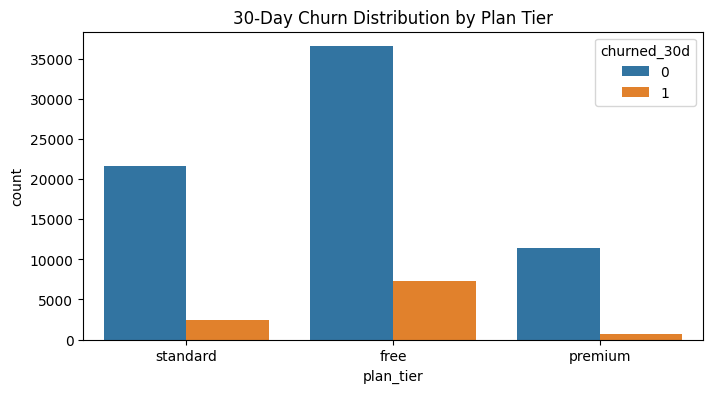

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

temp_df = X_train.copy()
temp_df[target_col] = y_train[target_col]

plt.figure(figsize=(8, 4))
sns.countplot(data=temp_df, x="plan_tier", hue=target_col)
plt.title("30-Day Churn Distribution by Plan Tier")
plt.show()

### 2.2 Feature extraction

We can also change features into values that might give us more information, or values that are easier for models to compute

For example, 
- We know that "user_id" provides no meaningful information whether customers churn or not
- Our ML model cannot handle data formats, and it helps to transform it into a single numerical value
- Similarly, True/False values should be turned into 0/1 values

In [18]:
X_train = X_train.drop("user_id", axis=1)

X_train["signup_month"] = pd.to_datetime(X_train["signup_date"]).dt.month
X_train = X_train.drop("signup_date", axis=1) 

X_train['is_enterprise'] = X_train['is_enterprise'].astype(int)

X_train

,plan_tier,company_size,industry,acquisition_channel,is_enterprise,downgraded,expansion_event,region_imputed,signup_month
0,standard,1-10,energy,outbound,0,0,1,APAC,4
1,free,1-10,healthcare,ads,0,0,1,EU,6
2,free,1-10,manufacturing,ads,0,0,1,EU,4
3,standard,51-200,education,ads,0,0,0,APAC,7
4,premium,11-50,healthcare,seo,0,0,0,APAC,7
...,...,...,...,...,...,...,...,...,...
79995,free,51-200,retail,seo,0,0,1,APAC,4
79996,standard,1-10,education,seo,0,0,1,EU,5
79997,free,200+,retail,partner,0,0,0,APAC,3
79998,free,200+,manufacturing,ads,0,0,0,EU,5


### 2.3 Encoding
Similarly, ML models are bad at working with categorical data. It is much better to have them in a numerical format. 

One way to do this is through encoding, essentially labelling the different categories with different numbers. 

Nominal encoding refers to labelling while providing an order to our labels. This is helpful when order matters in our data, for example for the feature "company_size"

One hot encoding refers to labelling with no inherent order. This is useful when there is no order in our data.

In [ ]:
X_train["plan_tier"].unique()

In [ ]:
X_train["company_size"].unique()

In [19]:
tier_mapping = {
    "standard": 0,
    "free": 1, 
    "premium": 2
}

tier_company_size = {
    "1-10": 0, 
    "11-50": 1, 
    "51-200": 2, 
    "200+": 3
}

X_train["plan_tier_encoded"] = X_train["plan_tier"].map(tier_mapping)
X_train["company_size_encoded"] = X_train["company_size"].map(tier_company_size)

X_train = X_train.drop(columns=["plan_tier", "company_size"])

In [20]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = ["region_imputed", "industry", "acquisition_channel"]

encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded_array = encoder.fit_transform(X_train[cat_cols])

encoded_col_names = encoder.get_feature_names_out(cat_cols)

encoded_df = pd.DataFrame(encoded_array, columns=encoded_col_names, index=X_train.index)

X_train_encoded = pd.concat([X_train.drop(columns=cat_cols), encoded_df], axis=1)

X_train_encoded

,is_enterprise,downgraded,expansion_event,signup_month,plan_tier_encoded,company_size_encoded,region_imputed_EU,region_imputed_LATAM,industry_energy,industry_finance,industry_healthcare,industry_manufacturing,industry_media,industry_retail,industry_software,industry_telecom,industry_transport,acquisition_channel_outbound,acquisition_channel_partner,acquisition_channel_seo
0,0,0,1,4,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0,0,1,6,1,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,1,4,1,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,7,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,7,2,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,0,0,1,4,1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
79996,0,0,1,5,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
79997,0,0,0,3,1,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
79998,0,0,0,5,1,3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Correlation Analysis

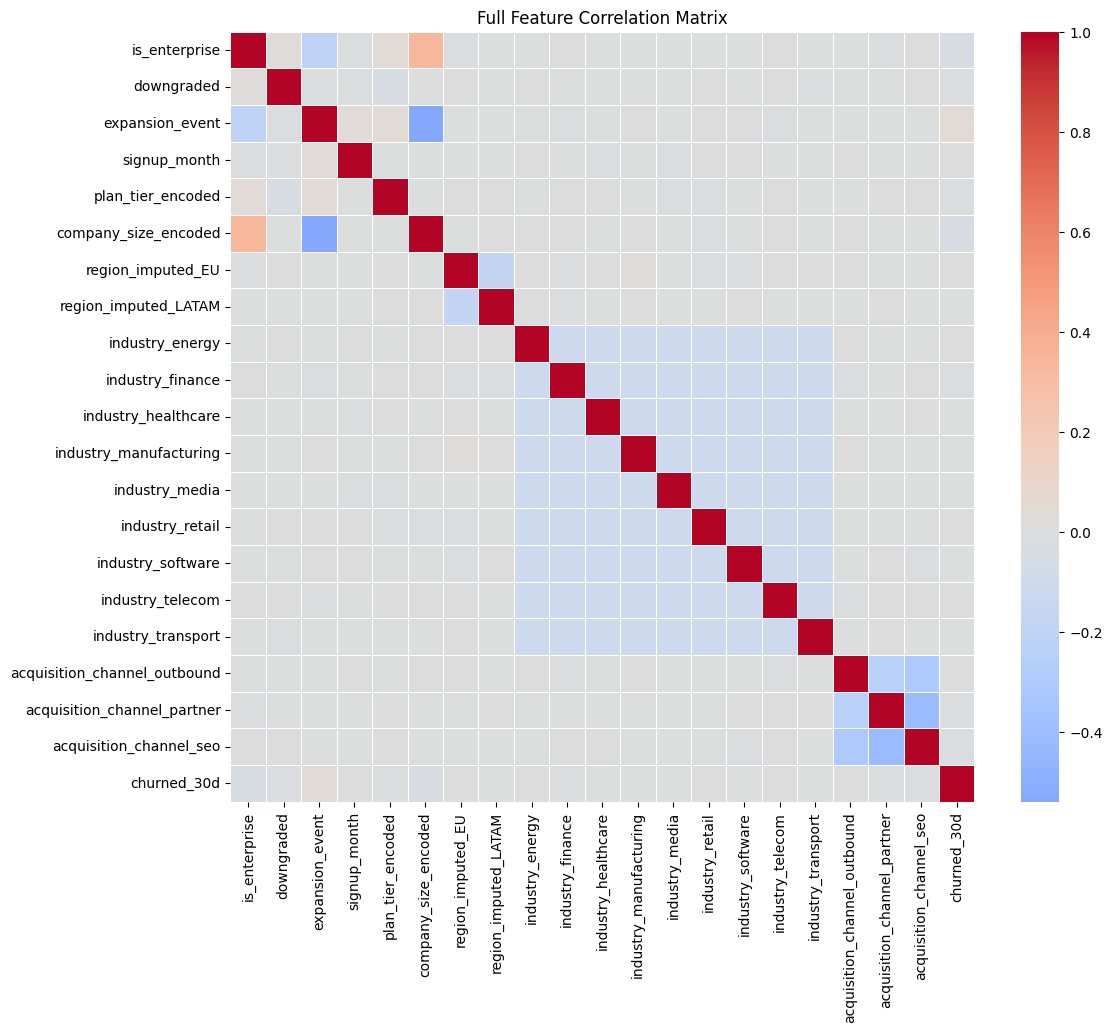

In [23]:
train_full = X_train_encoded.copy()
train_full[target_col] = y_train[target_col]

corr_matrix = train_full.corr()

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, 
            annot=False,    
            cmap='coolwarm', 
            center=0,
            linewidths=0.5) 

plt.title("Full Feature Correlation Matrix")
plt.show()

A lot of values have low correlation values with our target feature :(

There may be a few reasons for this:

1. This is calculating the Pearson correlation (linear). If they follow a non-linear pattern, then it won't show here. We can try other correlation metrics such as Spearman, Kendall-Tau, etc. 

2. These features may not be the best. Try creating features from other datasets provided in the actual hackathon! They may convey more useful information.

In [24]:
correlations = corr_matrix[target_col].abs()
strong_features = correlations[correlations > 0.05].index.tolist()
strong_features.remove(target_col)

print(f"Selected {len(strong_features)} features:\n{strong_features}")
X_train_final = X_train_encoded[strong_features]

Selected 0 features:
[]
